In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import os

# For progress bars
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
import os
import shutil

# --- Configuration ---

# 1. SET YOUR SOURCE FOLDER:
# Find your dataset path in the "Input" section of your notebook's sidebar.
# It will look something like '/kaggle/input/your-dataset-name' or 
# '/kaggle/input/your-dataset-name/images'
SOURCE_FOLDER = '/kaggle/input/melspectds/mel_images' # <-- CHANGE THIS

# 2. SET YOUR DESTINATION FOLDER:
# This will be created in your '/kaggle/working/' directory.
# You can see this in the "Output" section.
DESTINATION_BASE_FOLDER = '/kaggle/working/organized_images'

# --- End Configuration ---

# Create the base destination folder if it doesn't exist
os.makedirs(DESTINATION_BASE_FOLDER, exist_ok=True)
print(f"Organizing files from: {SOURCE_FOLDER}")
print(f"Saving to:           {DESTINATION_BASE_FOLDER}\n")

# Check if the source folder exists
if not os.path.exists(SOURCE_FOLDER):
    print(f"🚨 ERROR: Source folder not found: {SOURCE_FOLDER}")
    print("Please double-check your dataset path in the 'Input' sidebar.")
else:
    # Iterate over all entries in the source folder
    for entry in os.scandir(SOURCE_FOLDER):
        if not entry.is_file():
            continue
            
        filename = entry.name
        
        # Check for image extensions
        if not (filename.lower().endswith('.png') or 
                filename.lower().endswith('.jpg') or 
                filename.lower().endswith('.jpeg')):
            print(f"Skipping non-image file: {filename}")
            continue

        try:
            # Get filename without extension, e.g., "img_1000_14_1"
            base_name = os.path.splitext(filename)[0]
            
            # Split by underscore, e.g., ["img", "1000", "14", "1"]
            parts = base_name.split('_')
            
            # The class number is the 3rd part (index 2)
            class_number = parts[2]
            
            # Define the destination folder name, e.g., "class_14"
            dest_folder_name = f"class_{class_number}"
            dest_path = os.path.join(DESTINATION_BASE_FOLDER, dest_folder_name)
            
            # Create the destination class folder if it doesn't exist
            os.makedirs(dest_path, exist_ok=True)
            
            # Get the full old and new paths for the file
            source_file_path = entry.path
            dest_file_path = os.path.join(dest_path, filename)
            
            # *** KEY KAGGLE CHANGE ***
            # Use shutil.copy() because /kaggle/input is READ-ONLY.
            # We cannot 'move' files, we must 'copy' them to /kaggle/working.
            shutil.copy(source_file_path, dest_file_path)
            # print(f"Copied: {filename}  ->  {dest_folder_name}")

        except IndexError:
            # This handles files that don't match the "img_1000_14_1" format
            print(f"Skipping file (mismatched format): {filename}")
        except Exception as e:
            # Catch other potential errors
            print(f"Error processing {filename}: {e}")

    print("\n✅ File organization complete.")

Organizing files from: /kaggle/input/melspectds/mel_images
Saving to:           /kaggle/working/organized_images


✅ File organization complete.


In [4]:
!pip install timm

In [5]:
# This is the folder you created in the previous step
DATA_DIR = '/kaggle/working/organized_images'

# ViT models are typically trained on 224x224 or 256x256 images
IMG_SIZE = 224
BATCH_SIZE = 32 # Adjust based on your GPU memory (16, 32, 64)
EPOCHS = 25     # Start with 10-20 and see how it does
LR = 1e-4       # Learning rate

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. Define Data Transforms ---

# ViT models require specific normalization (ImageNet stats)
# Even though spectrograms are often 1-channel, we load them as 3-channel (RGB)
# because the pre-trained ViT expects a 3-channel input.
# The `ImageFolder` loader handles this conversion automatically.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        # Add augmentations for robustness
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
}

# --- 3. Load Dataset and Create DataLoaders ---

# Load the entire dataset using ImageFolder
try:
    full_dataset = datasets.ImageFolder(DATA_DIR)
except FileNotFoundError:
    print(f"🚨 ERROR: Directory not found at {DATA_DIR}")
    print("Please make sure the 'organized_images' folder exists in '/kaggle/working/'")
    # Stop execution if path is wrong
    raise

# Get the number of classes automatically from ImageFolder
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes
print(f"Found {num_classes} classes: {class_names}")

# Split the dataset into training and validation
# Let's use an 80/20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# IMPORTANT: Apply the *correct* transforms to each split
train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nTraining set size: {len(train_dataset)} images")
print(f"Validation set size: {len(val_dataset)} images")

Using device: cuda
Found 27 classes: ['class_1', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19', 'class_2', 'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9']

Training set size: 1620 images
Validation set size: 405 images


In [6]:
# Load a pre-trained ViT model
# 'vit_base_patch16_224' is a popular and strong baseline
model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=num_classes  # This automatically replaces the head
)

# Move the model to the GPU
model = model.to(device)

# You can uncomment this to see the model architecture
# print(model)

In [7]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
# AdamW is often preferred for Transformer models
optimizer = optim.AdamW(model.parameters(), lr=LR)

In [8]:
print("Starting training...")

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()  # Set model to training mode
    running_loss = 0.0
    running_corrects = 0
    
    # Wrap train_loader with tqdm for a progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for inputs, labels in train_pbar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
        # Update progress bar description
        train_pbar.set_postfix({'loss': loss.item()})

    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects.double() / len(train_dataset)

    # --- Validation Phase ---
    model.eval()   # Set model to evaluate mode
    val_running_loss = 0.0
    val_running_corrects = 0
    
    # Wrap val_loader with tqdm for a progress bar
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")

    with torch.no_grad(): # No gradients needed for validation
        for inputs, labels in val_pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            
            val_pbar.set_postfix({'loss': loss.item()})

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_running_corrects.double() / len(val_dataset)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    print("-" * 20)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc.item()) # Use .item() to get Python number
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc.item()) # Use .item() to get Python number

print("✅ Training complete.")

# --- Optional: Save your model ---
# You can find the saved file in the "Output" section of the sidebar
torch.save(model.state_dict(), 'vit_spectrogram_model.pth')
print("Model saved to vit_spectrogram_model.pth")

Starting training...


Epoch 1/25 [Val]: 100%|██████████| 13/13 [00:04<00:00,  2.98it/s, loss=1.25]


Epoch 1/25
Train Loss: 2.2496 Acc: 0.3278
Val   Loss: 1.4252 Acc: 0.5556
--------------------


Epoch 2/25 [Val]: 100%|██████████| 13/13 [00:04<00:00,  2.69it/s, loss=0.805]


Epoch 2/25
Train Loss: 1.0735 Acc: 0.6648
Val   Loss: 1.0280 Acc: 0.7062
--------------------


...

Epoch 23/25
Train Loss: 0.0991 Acc: 0.9747
Val   Loss: 1.0600 Acc: 0.7605
--------------------


Epoch 24/25 [Val]: 100%|██████████| 13/13 [00:04<00:00,  2.66it/s, loss=1.3] 


Epoch 24/25
Train Loss: 0.0610 Acc: 0.9815
Val   Loss: 1.3438 Acc: 0.7111
--------------------


Epoch 25/25 [Val]: 100%|██████████| 13/13 [00:04<00:00,  2.66it/s, loss=1.24] 


Epoch 25/25
Train Loss: 0.0214 Acc: 0.9932
Val   Loss: 1.1954 Acc: 0.7506
--------------------
✅ Training complete.
Model saved to vit_spectrogram_model.pth


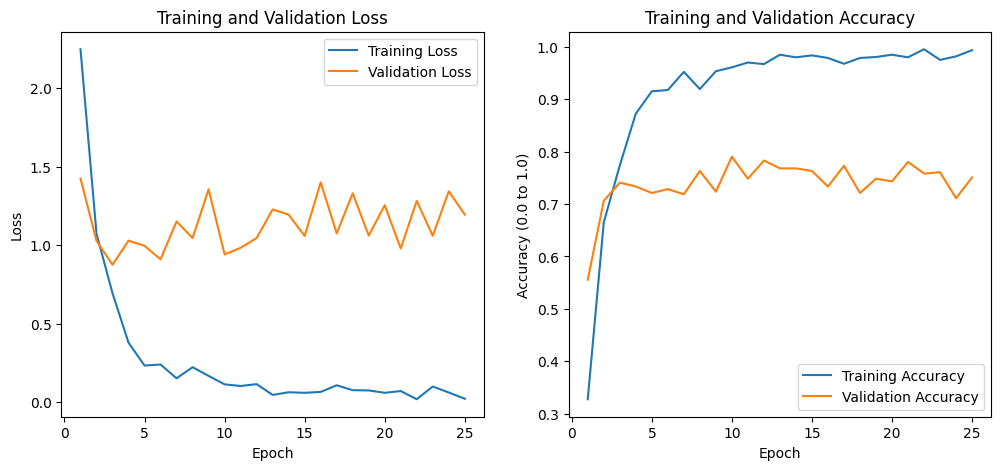

In [9]:
import matplotlib.pyplot as plt

# Get the number of epochs
epochs_range = range(1, EPOCHS + 1)

# Plot Training & Validation Loss
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Training Loss')
plt.plot(epochs_range, val_loss_history, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label='Training Accuracy')
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (0.0 to 1.0)')

# Save the figure (optional, but good for Kaggle)
# You can find the file in the "Output" section
plt.savefig('training_plots.png')

# Show the plot
plt.show()